# FWI Imaging · Acoustic VRZ · Marmousi (vector reflectivity from impedance)

A multiparameter FWI **imaging** workflow on the variable-density VRZ acoustic
equation. We invert velocity `vp` and acoustic **impedance** `z = vp·rho`, then
form the **vector reflectivity** (Whitmore et al., 2020) — the imaging deliverable — from the inverted
impedance:

$$\mathbf{R} \;=\; \tfrac{1}{2}\,\frac{\nabla Z}{Z}\;=\;-\tfrac{1}{2}\,Z\,\nabla\!\Big(\tfrac{1}{Z}\Big)\;=\;\tfrac{1}{2}\,\nabla(\ln Z).$$

`AcousticVRZ` writes the 2nd-order system with `b = vp/z` and `κ = z·vp`; the
`∇b·∇p` term means the wavefield reflects at impedance contrasts, and the
**normalized rate of impedance change** `½ ∇Z/Z` *is* the vector reflectivity
that the data sees. So inverting `z` and differentiating gives a reflector image.

**Why this works well.** `R` depends only on the impedance `Z`, not on `vp`. In
this joint inversion `Z` is the better-constrained, faster-converging parameter
(reflections directly constrain impedance), so the reflectivity image stabilises
quickly even though `vp` converges more slowly.

Workflow:

1. load embedded `vp` **and** `rho` from `sweep.datasets`, build `z = vp·rho`
2. build geometry, wavelet, and the `AcousticVRZ` solver
3. forward-model the observed data **once** from the true `(vp, z)`
4. jointly invert the smooth start with Adam + MSE, multiscale by **filtering**
5. compare inverted `vp` / `z`, then **image the vector reflectivity** `R = ½∇Z/Z`

## Note on units & matching the learning rates

We invert `vp` and `z` directly, so we want them on the **same order of
magnitude**. `z = vp·rho` only enters the PDE through `κ=z·vp` and `b=vp/z`, whose
products (`κ·b=vp²`, `κ·∇b`) are **invariant to the absolute scale of `z`** — so
the modeled data is unaffected by the density unit; only conditioning is. With
density in **g/cm³** (~1.0–2.6), `z` lands at **~10³–10⁴** (same order as `vp`),
so `lr_vp` and `lr_z` are kept the same order (≈20 vs ≈25). With kg/m³, `z` would
be ~10⁷ and force `lr_z ~ 10⁴`. As in nb01 we keep `eps=1e-16`.

## Note on frequency, grid & multiscale

For a sharper image we run up to a **12 Hz** Ricker on the **full-resolution
12.5 m** Marmousi grid (no `::2` downsample). At `dh=12.5 m` most of the model is
dispersion-safe at this frequency; only the slowest near-surface (`vp≈1 km/s`)
is mildly under-sampled (~3 points per shortest wavelength), which is acceptable
here. `dt=0.001 s` keeps the Courant number ≈0.38.

Starting a 12 Hz inversion straight from the smooth model **cycle-skips** (the
models *and* the image get worse). The fix is **multiscale frequency
continuation by filtering** (Bunks): model the observed data **once** with the
12 Hz wavelet, then **low-pass both predicted and observed** to a rising band
(`3 → 5 → 8 Hz → full`). Inverting the low band first recovers the smooth
background without cycle-skipping; opening the band warm-starts higher
resolution. This filters a single fixed dataset — exactly how multiscale is done
on real field data — rather than re-modelling with a different wavelet per band.

## 1. Parameters

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

from sweep.equations import AcousticVRZ
from sweep.propagator.torch import PropTorch
from sweep.signal import ricker
from sweep.datasets import load_marmousi, MARMOUSI_DH

dh    = MARMOUSI_DH       # 12.5 m — full embedded resolution (no downsample)
dt    = 0.001             # Courant ~0.38 at vp_max=4700, dh=12.5
nt    = 4000              # 4.0 s
freq  = 12.0             # single Ricker used for ALL forwards (obs modeled ONCE)
delay = 0.12
nshots, nrec, batch_shots = 20, 200, 8
src_z, rec_z = 4, 8       # grid indices -> 50 m / 100 m depth at dh=12.5

# With rho in g/cm^3, z ~ vp in magnitude, so lr_vp and lr_z are the same order.
lr_vp, lr_z = 20.0, 25.0
# Multiscale by FILTERING (Bunks): model obs ONCE at `freq`, then low-pass pred+obs
# to each band. Schedule = (low-pass corner Hz | None = full band, iterations).
freq_schedule = [(3.0, 15), (5.0, 15), (8.0, 15), (None, 15)]
n_iter = sum(it for _, it in freq_schedule)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


## 2. Load Marmousi `vp` + `rho`, build impedance `z`

`sweep.datasets` ships density as well as velocity, at the full 12.5 m grid.
Density is converted to **g/cm³** (divide the SI kg/m³ values by 1000) so
`z = vp·rho` stays on the same scale as `vp`:

```python
load_marmousi('rho_true')   / 1000.0   # kg/m^3 -> g/cm^3  (~1.0 .. 2.6)
load_marmousi('rho_smooth') / 1000.0
```

shape: (281, 1361)   extent: 3.5 km depth x 17.0 km offset
vp  range 1028..4700 m/s   rho range 1.01..2.63 g/cm^3
z = vp*rho range 1.515e+03..1.234e+04  (~ vp scale)


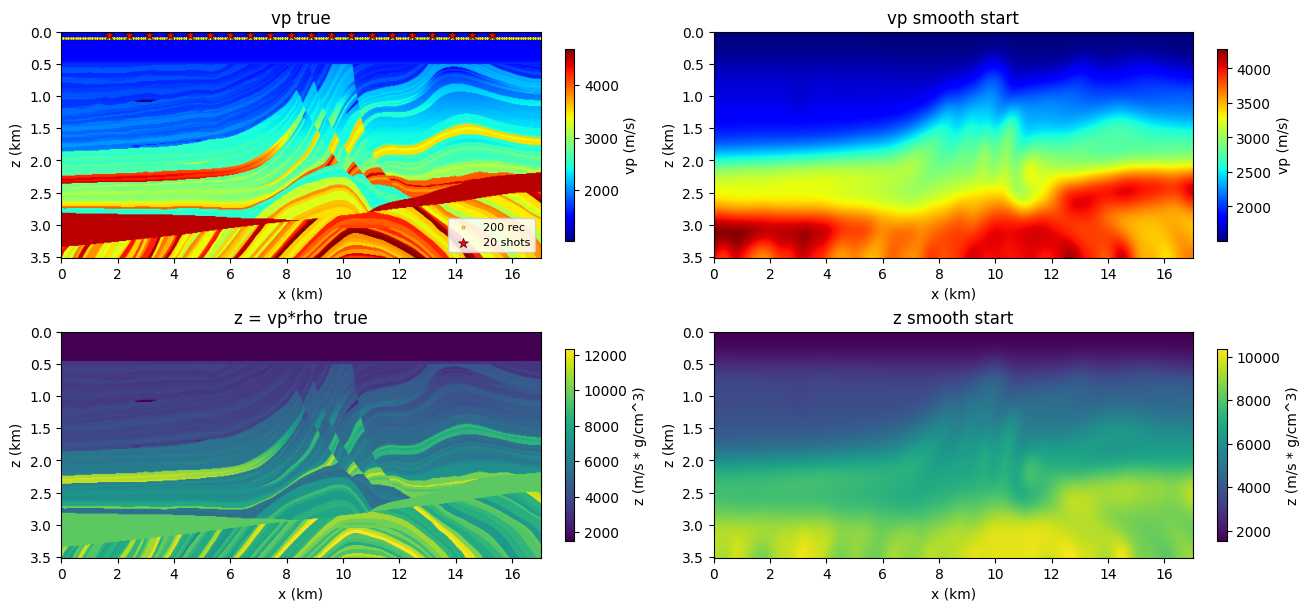

In [2]:
vp_true_np  = load_marmousi('vp_true').copy()
vp_init_np  = load_marmousi('vp_smooth').copy()
# density in g/cm^3 so that z = vp*rho ~ vp in magnitude (see note above)
rho_true_np = (load_marmousi('rho_true')   / 1000.0).astype(np.float32)
rho_init_np = (load_marmousi('rho_smooth') / 1000.0).astype(np.float32)

# Impedance z = vp * rho  (the second VRZ model parameter)
z_true_np = (vp_true_np * rho_true_np).astype(np.float32)
z_init_np = (vp_init_np * rho_init_np).astype(np.float32)

shape = vp_true_np.shape
print('shape:', shape, '  extent:',
      f'{shape[0]*dh/1000:.1f} km depth x {shape[1]*dh/1000:.1f} km offset')
print(f'vp  range {vp_true_np.min():.0f}..{vp_true_np.max():.0f} m/s   '
      f'rho range {rho_true_np.min():.2f}..{rho_true_np.max():.2f} g/cm^3')
print(f'z = vp*rho range {z_true_np.min():.3e}..{z_true_np.max():.3e}  (~ vp scale)')

# Acquisition geometry: surface sources + horizontal receiver line
src_x = np.linspace(shape[1] * 0.1, shape[1] * 0.9, nshots).astype(np.int64)
rec_x = np.linspace(0, shape[1] - 1, nrec).astype(np.int64)
src_x_km, src_z_km = src_x * dh / 1000, src_z * dh / 1000
rec_x_km, rec_z_km = rec_x * dh / 1000, rec_z * dh / 1000

extent = [0, shape[1]*dh/1000, shape[0]*dh/1000, 0]
fig, axes = plt.subplots(2, 2, figsize=(13, 6), constrained_layout=True)
panels = [(axes[0,0], vp_true_np, 'vp true', 'jet', 'vp (m/s)'),
          (axes[0,1], vp_init_np, 'vp smooth start', 'jet', 'vp (m/s)'),
          (axes[1,0], z_true_np,  'z = vp*rho  true', 'viridis', 'z (m/s * g/cm^3)'),
          (axes[1,1], z_init_np,  'z smooth start', 'viridis', 'z (m/s * g/cm^3)')]
for ax, m, title, cmap, clab in panels:
    im = ax.imshow(m, cmap=cmap, aspect='auto', extent=extent)
    ax.set_title(title); ax.set_xlabel('x (km)'); ax.set_ylabel('z (km)')
    fig.colorbar(im, ax=ax, label=clab, shrink=0.85)
axes[0,0].scatter(rec_x_km, np.full_like(rec_x_km, rec_z_km, dtype=float),
                  s=5, c='yellow', edgecolors='k', linewidths=0.2, label=f'{nrec} rec')
axes[0,0].scatter(src_x_km, np.full_like(src_x_km, src_z_km, dtype=float),
                  s=55, c='red', marker='*', edgecolors='k', linewidths=0.4, label=f'{nshots} shots')
axes[0,0].legend(loc='lower right', fontsize=8, framealpha=0.85)
plt.show()

## 3. Geometry, wavelet, solver (`AcousticVRZ`)

Same defaults as nb01 (`spatial_order=4`, `abcn=50`, `pml_type='cpmlr'`,
`free_surface=False`, `use_ckpt=True`); only the equation changes. If the finer
grid runs out of GPU memory, drop `batch_shots`.

In [3]:
t = np.arange(nt, dtype=np.float32) * dt
wavelet = ricker(t - delay, f=freq)

sources   = np.stack([src_x, np.full(nshots, src_z, dtype=np.int64)], axis=1)
receivers = np.stack([rec_x, np.full(nrec, rec_z, dtype=np.int64)], axis=1)
receivers = np.repeat(receivers[None, ...], nshots, axis=0)

equation = AcousticVRZ(device=device)
solver   = PropTorch(equation, shape=shape, dh=dh, dt=dt, impl='c')
if solver.impl == 'eager':
    batch_shots = min(batch_shots, 2)
print('impl:', solver.impl, ' batch_shots:', batch_shots)

impl: c  batch_shots: 8


### Aside · `AcousticVRZ` takes two models, in order `(vp, z)`

The input model order matters — pass `models=[vp, z]`.

In [4]:
print('models (input order matters!):')
for spec in equation.MODEL_SPECS:
    unit = f' [{spec.unit}]' if spec.unit else ''
    print(f'  - {spec.name:8s}{unit}  -- {spec.description}')
print('defaults  :', equation.default_source_fields, '/', equation.default_receiver_fields)

models (input order matters!):
  - vp       [m/s]  -- Acoustic velocity model.
  - z         -- Auxiliary parameter used by the VRZ formulation.
defaults  : ['h1'] / ['h1']


## 4. Forward modeling — observed data

observed shape: (20, 4000, 200, 1)


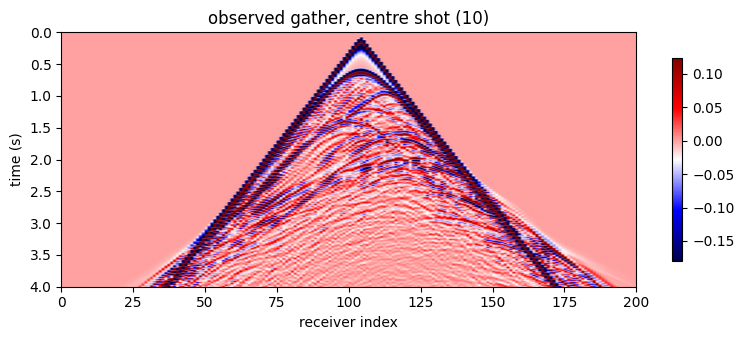

In [5]:
vp_true = torch.tensor(vp_true_np, device=device)
z_true  = torch.tensor(z_true_np,  device=device)
models_true = [vp_true, z_true]            # order: (vp, z)

with torch.no_grad():
    observed = solver(wavelet, sources, receivers, models=models_true).detach()
print('observed shape:', tuple(observed.shape))

gather0 = observed[nshots // 2].squeeze().detach().cpu().numpy()
if gather0.shape[0] != nt:
    gather0 = gather0.T
vmin, vmax = np.percentile(gather0, [2, 98])
plt.figure(figsize=(8, 3.5))
plt.imshow(gather0, cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto',
           extent=[0, nrec, nt * dt, 0])
plt.xlabel('receiver index'); plt.ylabel('time (s)')
plt.title(f'observed gather, centre shot ({nshots // 2})')
plt.colorbar(shrink=0.8); plt.tight_layout(); plt.show()

## 5. Multiscale joint inversion — `vp` **and** `z`

Multiscale by **filtering** (Bunks). The observed data was modeled **once**
(section 4) with the 12 Hz wavelet; each stage then **low-passes both predicted
and observed** to a band — `3 → 5 → 8 Hz → full` — instead of regenerating the
data with a new Ricker per band. This is how multiscale is run on real (fixed,
broadband) field data, and it needs only **one** observed-data forward. The
low-pass is a **differentiable FFT filter** applied identically to predicted and
observed, so the gradient sees the filtered misfit. The low bands recover the
smooth background without cycle-skipping; opening the band adds resolution. Each
stage uses a **fresh Adam** with **cosine LR decay** (the gradient scale changes
between bands, and the decay tames near-surface Adam overshoot), and each
iteration draws a random mini-batch of shots.

> **Caveat.** A 12 Hz Ricker is low-frequency-poor, so the low-pass bands have
> limited SNR and the final `full` stage can mildly cycle-skip `vp`. For a
> sharper image, drive the single forward with a broadband / low-frequency-rich
> source, or cap the final band (e.g. stop at ~8–10 Hz). The impedance `z` and
> the reflectivity image are robust regardless.

In [6]:
import time
rng = np.random.default_rng(0)

vp = torch.tensor(vp_init_np, device=device, requires_grad=True)
z  = torch.tensor(z_init_np,  device=device, requires_grad=True)

# Multiscale by FILTERING. The observed data was modeled ONCE (section 4,
# `observed`) with the freq=12 Hz `wavelet`; here we just low-pass both predicted
# and observed to each stage band — instead of regenerating obs with a new Ricker
# per band. That single broadband forward + per-band filtering is how multiscale
# is run on real (fixed) field data. `lowpass` is a differentiable FFT filter, so
# it sits inside the gradient, and the SAME filter is applied to predicted AND
# observed each stage.

def lowpass(x, corner):
    """Differentiable FFT low-pass along the time axis (the dim of size nt).
    Cosine taper from corner to 1.3*corner Hz. corner=None -> identity (full band)."""
    if corner is None:
        return x
    tdim = next(d for d in range(x.dim()) if x.shape[d] == nt)
    fr = torch.fft.rfftfreq(nt, dt).to(x.device)
    hi = corner * 1.3
    mask = torch.clamp((hi - fr) / (hi - corner), 0.0, 1.0)
    mask = torch.where(fr <= corner, torch.ones_like(fr), mask)
    shp = [1] * x.dim(); shp[tdim] = -1
    X = torch.fft.rfft(x, dim=tdim) * mask.reshape(shp)
    return torch.fft.irfft(X, n=nt, dim=tdim)

losses, stage_bounds = [], []
t_start = time.time()
for stage, (corner, iters) in enumerate(freq_schedule):
    obs_s = lowpass(observed, corner).detach()       # filter the once-modeled obs per stage
    optimizer = torch.optim.Adam([                    # fresh per stage (gradient scale changes)
        {'params': [vp], 'lr': lr_vp},
        {'params': [z],  'lr': lr_z},
    ], eps=1e-16)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=iters)
    for it in range(iters):
        idx = rng.choice(nshots, size=batch_shots, replace=False)
        optimizer.zero_grad()
        predicted = solver(wavelet, sources[idx], receivers[idx], models=[vp, z])
        loss = (lowpass(predicted, corner) - obs_s[idx]).pow(2).mean()
        loss.backward()
        optimizer.step(); scheduler.step()
        if device.type == 'cuda':
            torch.cuda.synchronize()
        losses.append(float(loss.detach().cpu()))
    stage_bounds.append(len(losses))
    band = 'full' if corner is None else f'{corner:.0f} Hz'
    print(f'stage {stage}  low-pass {band:>6}  ({iters} iters)  '
          f'loss {losses[-1]:.4e}  total={time.time()-t_start:.1f}s')

stage 0  low-pass   3 Hz  (15 iters)  loss 1.9250e-05  total=77.8s


stage 1  low-pass   5 Hz  (15 iters)  loss 1.0464e-04  total=155.8s


stage 2  low-pass   8 Hz  (15 iters)  loss 4.8715e-04  total=233.8s


stage 3  low-pass   full  (15 iters)  loss 3.1018e-03  total=311.6s


## 6. Inverted models — `vp` and `z`

vp  rel-RMS error : initial 0.1256  ->  inverted 0.1276
z   rel-RMS error : initial 0.1539  ->  inverted 0.1409  (converges faster than vp)


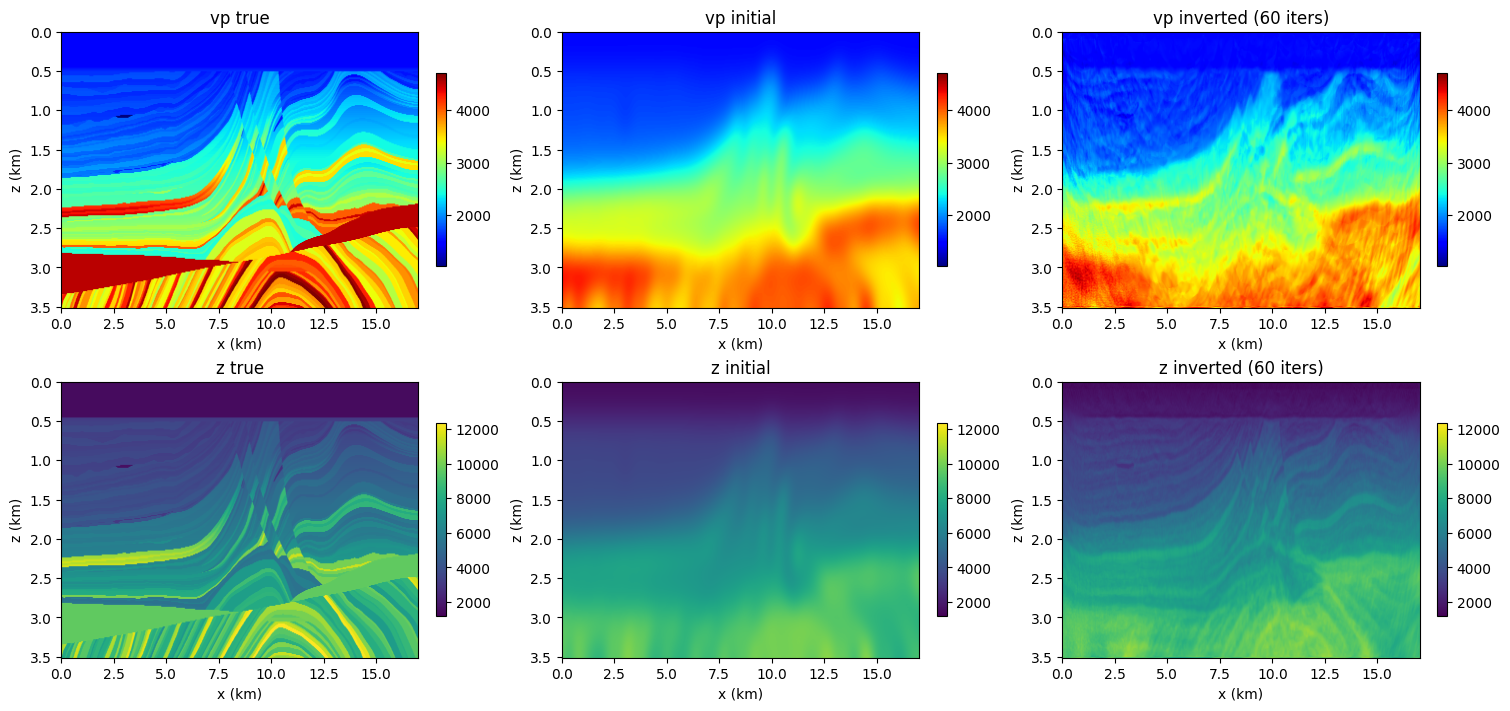

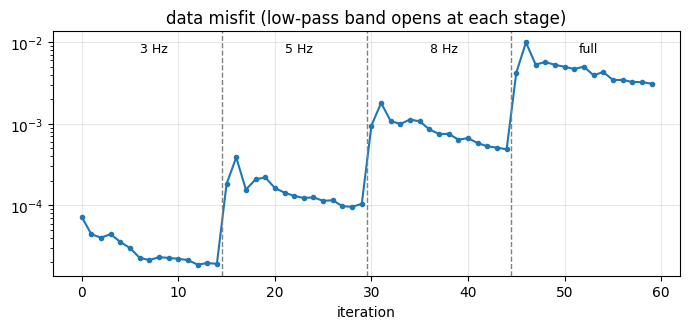

In [7]:
vp_final = vp.detach().cpu().numpy()
z_final  = z.detach().cpu().numpy()
x_trace  = shape[1] // 2
z_axis   = np.arange(shape[0]) * dh

def _lims(*arrs):
    return float(min(a.min() for a in arrs)), float(max(a.max() for a in arrs))
vp_lo, vp_hi = _lims(vp_true_np, vp_init_np, vp_final)
z_lo,  z_hi  = _lims(z_true_np,  z_init_np,  z_final)

def rel_rms(a, b):
    return float(np.sqrt(((a - b) ** 2).mean()) / np.sqrt((b ** 2).mean()))
print(f'vp  rel-RMS error : initial {rel_rms(vp_init_np, vp_true_np):.4f}'
      f'  ->  inverted {rel_rms(vp_final, vp_true_np):.4f}')
print(f'z   rel-RMS error : initial {rel_rms(z_init_np,  z_true_np):.4f}'
      f'  ->  inverted {rel_rms(z_final,  z_true_np):.4f}  (converges faster than vp)')

fig, axes = plt.subplots(2, 3, figsize=(15, 7), constrained_layout=True)
rows = [('vp', 'jet', vp_lo, vp_hi, [vp_true_np, vp_init_np, vp_final]),
        ('z',  'viridis', z_lo, z_hi, [z_true_np, z_init_np, z_final])]
col_titles = ['true', 'initial', f'inverted ({n_iter} iters)']
for r, (name, cmap, lo, hi, mats) in enumerate(rows):
    for c, (m, ct) in enumerate(zip(mats, col_titles)):
        ax = axes[r, c]
        im = ax.imshow(m, cmap=cmap, vmin=lo, vmax=hi, aspect='auto', extent=extent)
        ax.set_title(f'{name} {ct}'); ax.set_xlabel('x (km)'); ax.set_ylabel('z (km)')
        fig.colorbar(im, ax=ax, shrink=0.7)
plt.show()

plt.figure(figsize=(7, 3.4))
plt.plot(losses, marker='o', ms=3); plt.yscale('log')
x0 = 0
for (corner, _), x1 in zip(freq_schedule, stage_bounds):
    if x1 != stage_bounds[-1]:
        plt.axvline(x1 - 0.5, color='gray', ls='--', lw=1)
    lbl = 'full' if corner is None else f'{corner:.0f} Hz'
    plt.text((x0 + x1) / 2, max(losses), lbl, ha='center', va='top', fontsize=9)
    x0 = x1
plt.title('data misfit (low-pass band opens at each stage)')
plt.xlabel('iteration'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Imaging — vector reflectivity $\mathbf{R} = \tfrac12\,\nabla Z / Z$

The imaging deliverable. From the inverted impedance `Z` we form the **vector
reflectivity** (eq. 4),

$$\mathbf{R} = \tfrac12\,\frac{\nabla Z}{Z} = \tfrac12\,\nabla(\ln Z),
\qquad R_x = \tfrac12\,\frac{\partial_x Z}{Z},\quad R_z = \tfrac12\,\frac{\partial_z Z}{Z}.$$

`R` is the normalized rate of impedance change in each direction — large where
the subsurface has sharp impedance contrasts, i.e. **at reflectors**. So
differentiating the inverted impedance turns it into a reflector image. The
smooth starting model has almost no reflectivity; the inversion injects the
layering, and the inverted `R` should match the true-model reflectivity.

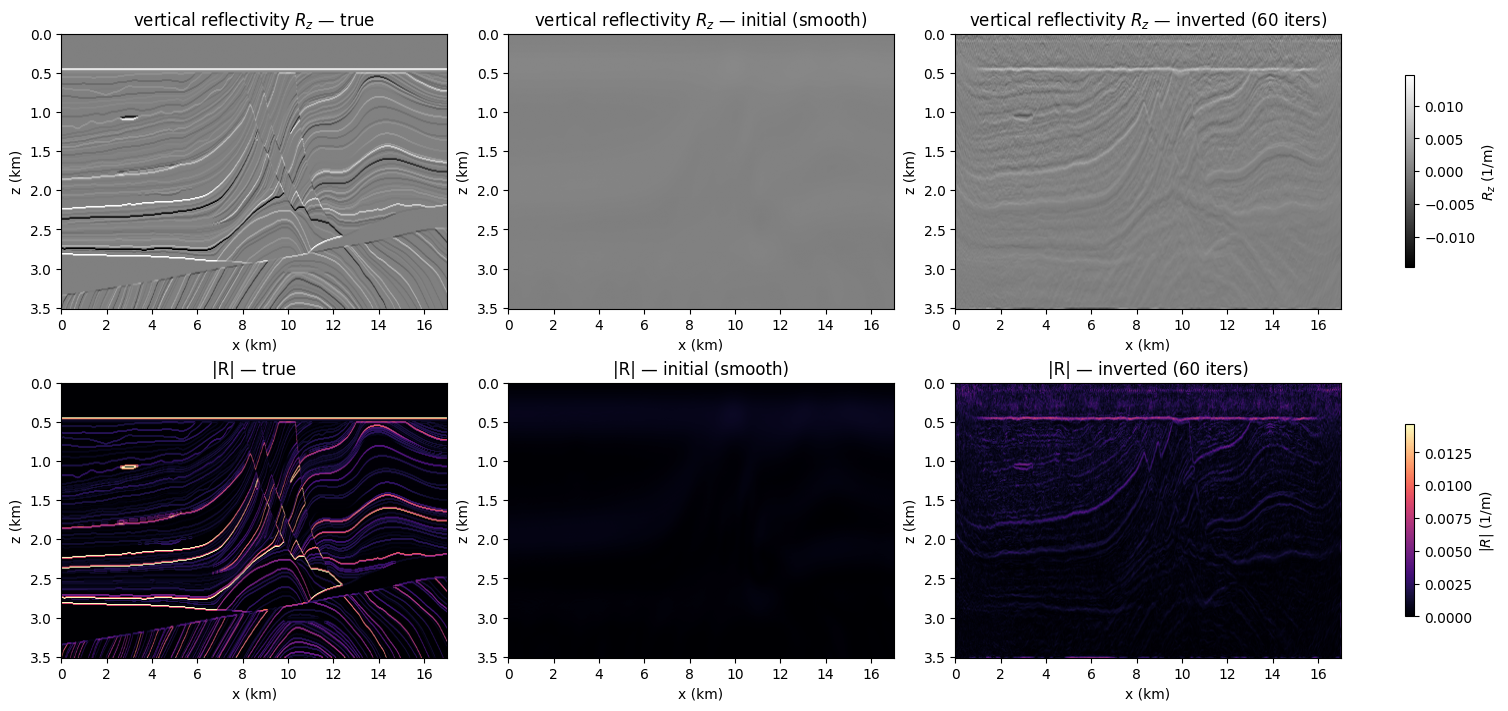

Rz rel-RMS vs true : initial 0.986  ->  inverted 0.929


In [8]:
def vector_reflectivity(Z, dh):
    """R = (1/2) grad(Z)/Z = (1/2) grad(ln Z). Returns (Rx, Rz, |R|).
    axis 0 = depth (z), axis 1 = lateral (x)."""
    Rz = 0.5 * np.gradient(Z, dh, axis=0) / Z
    Rx = 0.5 * np.gradient(Z, dh, axis=1) / Z
    return Rx, Rz, np.hypot(Rx, Rz)

Rx_true, Rz_true, Rm_true = vector_reflectivity(z_true_np, dh)
Rx_init, Rz_init, Rm_init = vector_reflectivity(z_init_np, dh)
Rx_inv,  Rz_inv,  Rm_inv  = vector_reflectivity(z_final,   dh)

# Signed percentile clip on the (two-sided) vertical reflectivity; shared so the
# three panels are directly comparable. |R| uses a 0..pct sequential scale.
rz_clip = float(np.percentile(np.abs(Rz_true), 99)) or 1e-12
rm_clip = float(np.percentile(Rm_true, 99)) or 1e-12

fig, axes = plt.subplots(2, 3, figsize=(15, 7), constrained_layout=True)
col_titles = ['true', 'initial (smooth)', f'inverted ({n_iter} iters)']
for c, (rz, rm, ct) in enumerate(zip([Rz_true, Rz_init, Rz_inv],
                                     [Rm_true, Rm_init, Rm_inv], col_titles)):
    im0 = axes[0, c].imshow(rz, cmap='gray',
                            norm=TwoSlopeNorm(vmin=-rz_clip, vcenter=0, vmax=rz_clip),
                            aspect='auto', extent=extent)
    axes[0, c].set_title(f'vertical reflectivity $R_z$ — {ct}')
    im1 = axes[1, c].imshow(rm, cmap='magma', vmin=0, vmax=rm_clip,
                            aspect='auto', extent=extent)
    axes[1, c].set_title(f'|R| — {ct}')
    for r in (0, 1):
        axes[r, c].set_xlabel('x (km)'); axes[r, c].set_ylabel('z (km)')
fig.colorbar(im0, ax=axes[0, :], shrink=0.7, label=r'$R_z$ (1/m)')
fig.colorbar(im1, ax=axes[1, :], shrink=0.7, label=r'$|R|$ (1/m)')
plt.show()

print(f'Rz rel-RMS vs true : initial {np.sqrt(((Rz_init-Rz_true)**2).mean())/np.sqrt((Rz_true**2).mean()):.3f}'
      f'  ->  inverted {np.sqrt(((Rz_inv-Rz_true)**2).mean())/np.sqrt((Rz_true**2).mean()):.3f}')

**Reading the image.** The vertical reflectivity $R_z$ from the inverted
impedance recovers the Marmousi layering and faults that the smooth start lacks
entirely. Because $\mathbf{R}=\tfrac12\nabla(\ln Z)$ depends only on $Z$ — the
fast-converging parameter — the reflector image is well resolved even where the
`vp` update is still smooth. This is the FWI-imaging payoff: invert for impedance,
differentiate, and read off the reflectors.

For a cleaner section one can taper the near-surface, band-pass $R_z$ to the
illuminated wavenumbers, or stack $R$ over multiple inversion restarts — beyond
this intro.

## Reference

Whitmore, N. D., Ramos-Martínez, J., Yang, Y., & Valenciano, A. A. (2020). Full wavefield modeling with vector reflectivity. *82nd EAGE Conference & Exhibition, Extended Abstracts*. [doi:10.3997/2214-4609.202010332](https://doi.org/10.3997/2214-4609.202010332) — the acoustic vector-reflectivity / impedance (`AcousticVRZ`) equation this notebook solves and images.

---

<p><strong>Download this notebook</strong> &mdash; <a href="17_fwi_vrz_marmousi.ipynb" download><code>17_fwi_vrz_marmousi.ipynb</code></a> &middot; or <a href="https://github.com/DeepWave-KAUST/sweep/blob/dev/examples/notebooks/17_fwi_vrz_marmousi.ipynb">view on GitHub</a></p>